# Exercise: Neural Networks

## 1. Import the required libraries in the cell below

In [16]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

## 2. Read the data

In [3]:
housing = pd.read_csv(r"C:\Users\jojah\GA_DSB\labs_projects\labs_projects\labs\NN\data\sacramento_real_estate_transactions.csv")
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768


## 3. Conduct Exploratory Data Analysis 

In [4]:
# Check data info
housing.info()


<class 'pandas.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   street     985 non-null    str    
 1   city       985 non-null    str    
 2   zip        985 non-null    int64  
 3   state      985 non-null    str    
 4   beds       985 non-null    int64  
 5   baths      985 non-null    int64  
 6   sq__ft     985 non-null    int64  
 7   type       985 non-null    str    
 8   sale_date  985 non-null    str    
 9   price      985 non-null    int64  
 10  latitude   985 non-null    float64
 11  longitude  985 non-null    float64
dtypes: float64(2), int64(5), str(5)
memory usage: 156.9 KB


In [5]:
# Check for missing values
housing.isnull().sum()

street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64

In [6]:
# Check data types
housing.dtypes

street           str
city             str
zip            int64
state            str
beds           int64
baths          int64
sq__ft         int64
type             str
sale_date        str
price          int64
latitude     float64
longitude    float64
dtype: object

In [8]:
# Look at the Summary Stats.
housing.describe()

,zip,beds,baths,sq__ft,price,latitude,longitude
count,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000
mean,95750.697462,2.911675,1.776650,1312.918782,233715.951269,38.445121,-121.193371
std,85.176072,1.307932,0.895371,856.123224,139088.818896,5.103637,5.100670
min,95603.000000,0.000000,0.000000,-984.000000,-210944.000000,-121.503471,-121.551704
25%,95660.000000,2.000000,1.000000,950.000000,145000.000000,38.482704,-121.446119
50%,95762.000000,3.000000,2.000000,1304.000000,213750.000000,38.625932,-121.375799
75%,95828.000000,4.000000,2.000000,1718.000000,300000.000000,38.695589,-121.294893
max,95864.000000,8.000000,5.000000,5822.000000,884790.000000,39.020808,38.668433


In [9]:
# Cleaning Steps (if needed)
# price/sq__ft have some negative and zero values that are clearly bad data
# (e.g. one row has a negative price, negative sq__ft, and swapped lat/long)
print((housing['price'] <= 0).sum(), 'rows with price <= 0')
print((housing['sq__ft'] <= 0).sum(), 'rows with sq__ft <= 0')

1 rows with price <= 0
172 rows with sq__ft <= 0


In [10]:
housing = housing[(housing['price'] > 0) & (housing['sq__ft'] > 0)].reset_index(drop=True)
housing.shape

(813, 12)

In [11]:
housing.describe()

,zip,beds,baths,sq__ft,price,latitude,longitude
count,813.000000,813.000000,813.000000,813.000000,813.000000,813.000000,813.000000
mean,95761.400984,3.247232,1.961870,1591.892989,229471.130381,38.576931,-121.378533
std,85.357516,0.849012,0.669367,663.908347,119897.576889,0.126352,0.119730
min,95603.000000,1.000000,1.000000,484.000000,2000.000000,38.241514,-121.550527
25%,95670.000000,3.000000,2.000000,1144.000000,148750.000000,38.473814,-121.451444
50%,95820.000000,3.000000,2.000000,1419.000000,207973.000000,38.591618,-121.404999
75%,95828.000000,4.000000,2.000000,1851.000000,285000.000000,38.674864,-121.325730
max,95864.000000,8.000000,5.000000,5822.000000,884790.000000,39.008159,-120.597599


## 4. Split the Data & Pre-Processing
**Best Practice for Neural Network** Split your data before modeling into three part:

1. __The Training Set (The Textbook):__ This is the data the neural network actually looks at to learn. During the training loop, the network uses this data to adjust its **weights** and **biases** via backpropagation.

2. __The Validation Set (The Practice Quiz):__ This data evaluates the model *during* training to fine-tune settings. The model does not learn its weights from this data. Instead, the it uses the validation score to choose **hyperparameters** (like learning rate, number of layers, or node count) and to decide when to stop training (**early stopping**).


3. __The Test Set (The Final Exam):__ This data provides an unbiased, final evaluation of the model's real-world performance. This dataset is locked away until training is completely finished. It is only used *once* at the very end to see how well the network performs on truly unseen data.

__Typical Split Ratios__

Depending on the size of your total dataset, data scientists generally use these proportions:

| Dataset Size | Train | Validation | Test |
| :--- | :--- | :--- | :--- |
| **Traditional (Small/Medium Data)** | 60% | 20% | 20% |
| **Modern Deep Learning (Millions of Rows)** | 98% | 1% | 1% |

In [12]:
# Select the Features and Target
X = housing[['sq__ft']]
y = housing['price']

print(X.shape, y.shape)

(813, 1) (813,)


In [13]:
# Split to Train Test & Validation
X_train_all, X_test, y_train_all, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_all, y_train_all, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)

(520, 1) (130, 1) (163, 1)


In [17]:
# IMPORTANT: Scale the features for Neural Networks
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val_scaled = y_scaler.transform(y_val.values.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

## 5. Linear Regression

In [19]:
# Initialize LinearRegression model
lr = LinearRegression()
lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
# Fit and check the Training Score
lr.fit(X_train_scaled, y_train)
lr.score(X_train_scaled, y_train)

0.5466522158004743

In [21]:
# Predict and check the Testing Score
y_pred_lr = lr.predict(X_test_scaled)
lr.score(X_test_scaled, y_test)

0.395499777045743

In [22]:
# Evaluate the model
print('Coefficient:', lr.coef_)
# Intercept
print('Intercept:', lr.intercept_)
# RMSE
lr_rmse = root_mean_squared_error(y_test, y_pred_lr)
print('RMSE:', lr_rmse)

Coefficient: [88401.52145413]
Intercept: 233264.86346153845
RMSE: 87635.43914425114


## 6. Build a Single Neural Network
Creating a model in `keras` entails a few steps:
1. Create your network topology
2. Compile your model
3. Fit your model
   
**Important Note on Regression:**
Because we are predicting a continuous value (house price), our network is performing regression, not classification. 
* Your **hidden layers** should generally use the `relu` activation function.
* Your **output layer** must have exactly **1 neuron** and **no activation function** (or `activation='linear'`) so it can predict any continuous number.
* When compiling, use `loss='mse'` (Mean Squared Error) and `metrics=['mae']` (Mean Absolute Error) so we can see the error in actual dollar amounts.

In [26]:
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(1))  # output layer: 1 neuron, no activation (linear)

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
model.fit(X_train_scaled, y_train_scaled, epochs=10)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4615 - mae: 0.5137  
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4600 - mae: 0.5130
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4591 - mae: 0.5124 
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4582 - mae: 0.5122 
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4573 - mae: 0.5114 
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4567 - mae: 0.5107
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4564 - mae: 0.5107 
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4559 - mae: 0.5103 
Epoch 9/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4553 - mae: 0.5101 
Epoch 10/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4551 - mae: 0.5100 


In [27]:
# Model Weights
model.weights

[<Variable path=sequential_3/dense_3/kernel, shape=(1, 1), dtype=float32, value=[[0.7042304]]>,
 <Variable path=sequential_3/dense_3/bias, shape=(1,), dtype=float32, value=[0.00635615]>]

In [28]:
# Model Summary
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6 (28.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4 (20.00 B)

## 7. Stacking Multiple Neurons

#### Shallow NN

In [32]:
# Step 1: Define
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(3, activation='relu'))  # hidden layer with 3 nodes
model.add(Dense(1))  # output layer

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
model.fit(X_train_scaled, y_train_scaled, epochs=10)

Epoch 1/10


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8120 - mae: 0.5952   
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7967 - mae: 0.5935 
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7880 - mae: 0.5912 
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7800 - mae: 0.5904 
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7735 - mae: 0.5883 
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7666 - mae: 0.5866 
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7606 - mae: 0.5845 
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7544 - mae: 0.5822 
Epoch 9/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7493 - mae: 0.5828 
Epoch 10/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7435 - mae: 0.5792 


In [33]:
# Model Weights
model.weights

[<Variable path=sequential_5/dense_6/kernel, shape=(1, 3), dtype=float32, value=[[-0.07215497 -1.1300043  -0.26303852]]>,
 <Variable path=sequential_5/dense_6/bias, shape=(3,), dtype=float32, value=[-0.01408814 -0.00882744  0.00974002]>,
 <Variable path=sequential_5/dense_7/kernel, shape=(3, 1), dtype=float32, value=[[-0.77747285]
  [-1.0676367 ]
  [ 1.0461802 ]]>,
 <Variable path=sequential_5/dense_7/bias, shape=(1,), dtype=float32, value=[0.14494504]>]

In [34]:
# Model Summary
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

#### Deep Network

In [36]:
# use multiple hidden layers with different neurons
# Step 1: Define
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(30, activation='relu'))  # hidden layer
model.add(Dense(20, activation='relu'))  # hidden layer
model.add(Dense(15, activation='relu'))  # hidden layer
model.add(Dense(1))   # output layer

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
model.fit(X_train_scaled, y_train_scaled, epochs=10)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9043 - mae: 0.6799   
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7324 - mae: 0.6065 
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6186 - mae: 0.5516 
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5534 - mae: 0.5274 
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5046 - mae: 0.5171 
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4805 - mae: 0.5072 
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4691 - mae: 0.5084 
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4632 - mae: 0.5051 
Epoch 9/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4623 - mae: 0.5063 
Epoch 10/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4606 - mae: 0.5070 


In [37]:
# Model Weights
model.weights

[<Variable path=sequential_7/dense_12/kernel, shape=(1, 30), dtype=float32, value=[[ 0.06832962 -0.4186799  -0.2944137  -0.3498212   0.39529514 -0.00941992
   -0.00155218  0.13519908 -0.3443471   0.40644732 -0.3195489   0.19099735
   -0.08165847  0.00750504  0.1209747   0.22379486 -0.37891176  0.01176882
   -0.18936871  0.39481044  0.31472224 -0.18647939 -0.29304063  0.15641801
    0.24409774 -0.11862735 -0.1886545  -0.37884796  0.49257663  0.08476771]]>,
 <Variable path=sequential_7/dense_12/bias, shape=(30,), dtype=float32, value=[ 0.05531453  0.00937442  0.00978749  0.04042257 -0.00308937 -0.0169684
  -0.00315853  0.03740945  0.03506105  0.04633387 -0.02774139 -0.02342841
   0.03852813 -0.04343159  0.03638728 -0.04057567  0.02493429 -0.05086806
  -0.01713143  0.05264265  0.01252065 -0.02248245  0.04260638  0.06070747
   0.01958727 -0.00516743  0.02085286  0.0258943   0.05767488 -0.03186127]>,
 <Variable path=sequential_7/dense_13/kernel, shape=(30, 20), dtype=float32, value=[[-0.185

In [38]:
# Model Summary
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 30)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 15)             │           315 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,024 (7.91 KB)

 Trainable params: 1,011 (3.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,013 (3.96 KB)

## 8. Activation Functions

In [39]:
# from keras.layers import Activation 
# Note: import Activation if you use it as a standalone layer
# Step 1: Define
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(3, activation='relu'))    # hidden layer with relu activation
model.add(Dense(1, activation='linear'))  # output layer with linear activation

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
model.fit(X_train_scaled, y_train_scaled, epochs=10)


Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9716 - mae: 0.6755  
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9374 - mae: 0.6615  
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9115 - mae: 0.6516 
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8881 - mae: 0.6426 
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8658 - mae: 0.6341 
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8459 - mae: 0.6257 
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8277 - mae: 0.6177 
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8120 - mae: 0.6119 
Epoch 9/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7969 - mae: 0.6055 
Epoch 10/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7829 - mae: 0.6003 


In [40]:
# Model Weights
model.weights

[<Variable path=sequential_8/dense_16/kernel, shape=(1, 3), dtype=float32, value=[[-0.760052    0.18984354 -1.2896086 ]]>,
 <Variable path=sequential_8/dense_16/bias, shape=(3,), dtype=float32, value=[ 0.03603227 -0.15254274  0.10531266]>,
 <Variable path=sequential_8/dense_17/kernel, shape=(3, 1), dtype=float32, value=[[-0.08074648]
  [-0.28791392]
  [-0.56068856]]>,
 <Variable path=sequential_8/dense_17/bias, shape=(1,), dtype=float32, value=[0.14014317]>]

In [41]:
# Model Summary
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

## 9. Epochs

In [45]:
# Step 1: Define
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(3, activation='relu'))
model.add(Dense(1, activation='linear'))

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
# 50 epochs means 50 complete passes of the training algorithm through the entire training set
model.fit(X_train_scaled, y_train_scaled, epochs=50)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5086 - mae: 0.5031  
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4912 - mae: 0.5001 
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4817 - mae: 0.5000 
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4763 - mae: 0.4985 
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4708 - mae: 0.4999 
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4669 - mae: 0.5004 
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4650 - mae: 0.5005 
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4629 - mae: 0.5014 
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4616 - mae: 0.5004 
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4599 - mae: 0.5016  
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4589 - mae: 0.5022 
Epoch 12/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4579 - mae: 0.5017 
Epoch 13/50
17/17 ━━━━━━━━━━━━━━━━━

In [46]:
# Model Weights
model.weights

[<Variable path=sequential_10/dense_20/kernel, shape=(1, 3), dtype=float32, value=[[ 0.6169047  -0.6798677  -0.45528054]]>,
 <Variable path=sequential_10/dense_20/bias, shape=(3,), dtype=float32, value=[ 0.03688817 -0.01729006 -0.05058791]>,
 <Variable path=sequential_10/dense_21/kernel, shape=(3, 1), dtype=float32, value=[[ 1.057489 ]
  [-0.7914009]
  [-0.8473952]]>,
 <Variable path=sequential_10/dense_21/bias, shape=(1,), dtype=float32, value=[0.05240223]>]

In [47]:
# Model Summary
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

## 10. Batch size (Chunks)

In [49]:
# Use the validation
# Step 1: Define
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(3, activation='relu'))
model.add(Dense(1, activation='linear'))

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
          epochs=50, batch_size=32)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.4416 - mae: 0.8639 - val_loss: 1.4992 - val_mae: 0.9080
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3299 - mae: 0.8372 - val_loss: 1.4211 - val_mae: 0.8941
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2436 - mae: 0.8171 - val_loss: 1.3408 - val_mae: 0.8799
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1695 - mae: 0.7974 - val_loss: 1.2782 - val_mae: 0.8677
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1020 - mae: 0.7794 - val_loss: 1.2171 - val_mae: 0.8544
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0369 - mae: 0.7617 - val_loss: 1.1629 - val_mae: 0.8408
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9802 - mae: 0.7446 - val_loss: 1.1143 - val_mae: 0.8263
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9255 - mae: 0.7284 - val_loss: 1.0692 - val_mae: 0.8111
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8771 - mae

In [50]:
# Model Weights
model.weights

[<Variable path=sequential_12/dense_24/kernel, shape=(1, 3), dtype=float32, value=[[-0.00610679  0.91305804  1.4899483 ]]>,
 <Variable path=sequential_12/dense_24/bias, shape=(3,), dtype=float32, value=[-0.01542083 -0.25147256  0.36288568]>,
 <Variable path=sequential_12/dense_25/kernel, shape=(3, 1), dtype=float32, value=[[ 1.2017921]
  [-0.5278611]
  [ 0.7966219]]>,
 <Variable path=sequential_12/dense_25/bias, shape=(1,), dtype=float32, value=[-0.39770624]>]

In [51]:
# Model Summary
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

Try a different batch size. 

__Note:__ the best practice to have the value in powers of 2

In [52]:
# Use the validation
# Step 1: Define
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(3, activation='relu'))
model.add(Dense(1, activation='linear'))

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
# batch size of 128 - fewer weight updates per epoch than batch_size=32
model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
          epochs=50, batch_size=128)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.8536 - mae: 0.6638 - val_loss: 0.9672 - val_mae: 0.7190
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.8427 - mae: 0.6590 - val_loss: 0.9581 - val_mae: 0.7149
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8337 - mae: 0.6555 - val_loss: 0.9499 - val_mae: 0.7111
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.8257 - mae: 0.6518 - val_loss: 0.9415 - val_mae: 0.7086
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.8165 - mae: 0.6489 - val_loss: 0.9348 - val_mae: 0.7054
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8097 - mae: 0.6459 - val_loss: 0.9276 - val_mae: 0.7029
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8019 - mae: 0.6433 - val_loss: 0.9207 - val_mae: 0.6994
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.7949 - mae: 0.6400 - val_loss: 0.9135 - val_mae: 0.6959
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.7876 - mae: 0.6369 - 

In [53]:
# Model Weights
model.weights

[<Variable path=sequential_13/dense_26/kernel, shape=(1, 3), dtype=float32, value=[[ 0.85997456  0.2974832  -1.1558844 ]]>,
 <Variable path=sequential_13/dense_26/bias, shape=(3,), dtype=float32, value=[0.21619433 0.20499793 0.19938307]>,
 <Variable path=sequential_13/dense_27/kernel, shape=(3, 1), dtype=float32, value=[[ 0.22435851]
  [ 0.30283025]
  [-0.5555805 ]]>,
 <Variable path=sequential_13/dense_27/bias, shape=(1,), dtype=float32, value=[0.11021617]>]

In [54]:
# Model Summary
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

## 11. History

**The Three Main Reasons to Use History**
  1. To Spot Overfitting
  2. To Visualise the Learning Curve
  3. To Know When to Stop Training

By saving the output of `model.fit()` to a variable (usually called `history`), Keras keeps a record of the training loss and validation loss at the end of each epoch. 

Plotting these two lines together helps us diagnose our model:
* If training loss goes down but validation loss goes up, the model is **overfitting** (memorizing the training data).
* If both are going down, the model is still learning.
* If both have flattened out, the model has converged and stopped learning.

In [55]:
# Use the validation
# Step 1: Define
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(3, activation='relu'))
model.add(Dense(1, activation='linear'))

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
history = model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
                     epochs=50, batch_size=32) 

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1.1695 - mae: 0.8910 - val_loss: 1.9158 - val_mae: 0.9920
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0782 - mae: 0.8527 - val_loss: 1.8041 - val_mae: 0.9538
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0119 - mae: 0.8231 - val_loss: 1.7161 - val_mae: 0.9227
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9539 - mae: 0.7975 - val_loss: 1.6251 - val_mae: 0.8887
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8999 - mae: 0.7718 - val_loss: 1.5444 - val_mae: 0.8581
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8514 - mae: 0.7499 - val_loss: 1.4718 - val_mae: 0.8312
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8099 - mae: 0.7292 - val_loss: 1.4086 - val_mae: 0.8086
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7725 - mae: 0.7101 - val_loss: 1.3419 - val_mae: 0.7843
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7380 - ma

In [56]:
# Model Weights
model.weights

[<Variable path=sequential_14/dense_28/kernel, shape=(1, 3), dtype=float32, value=[[-0.38935518 -0.29189658  0.90937895]]>,
 <Variable path=sequential_14/dense_28/bias, shape=(3,), dtype=float32, value=[ 0.19372584 -0.44708663  0.19329084]>,
 <Variable path=sequential_14/dense_29/kernel, shape=(3, 1), dtype=float32, value=[[-0.4869857 ]
  [ 0.39797366]
  [ 0.86652464]]>,
 <Variable path=sequential_14/dense_29/bias, shape=(1,), dtype=float32, value=[-0.23875384]>]

In [57]:
# Model Summary
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

In [58]:
# Create a History Data Frame
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,val_loss,val_mae
0,1.169494,0.891002,1.915806,0.991978
1,1.078226,0.852662,1.804065,0.953808
2,1.011867,0.823101,1.716101,0.922701
3,0.953917,0.797455,1.625134,0.888724
4,0.899873,0.771757,1.544399,0.858057
5,0.851450,0.749868,1.471795,0.831170
6,0.809857,0.729162,1.408637,0.808581
7,0.772476,0.710107,1.341868,0.784337
8,0.737972,0.691265,1.293163,0.764390
9,0.711126,0.676371,1.252428,0.746620


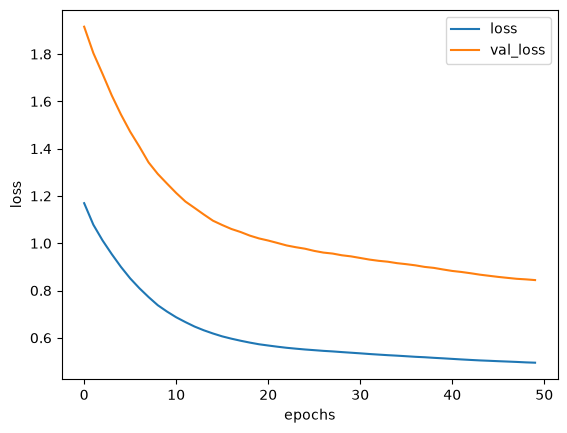

In [59]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
history_df[['loss', 'val_loss']].plot()
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

## 12. Early Stopping (callback)

- Prevent overfitting
- will not waste the computing power
- save time
  
It is hard to guess exactly how many epochs a model needs. If you train for too few epochs, the model underfits. If you train for too many, it overfits. 

An **Early Stopping Callback** acts as an automatic brake. It monitors the validation loss and automatically stops training once the validation score stops improving, even if you haven't reached your maximum number of epochs. It can also automatically restore the model's best weights!

In [60]:
# configure EarlyStopping parameters
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [61]:
# Use the validation
# Step 1: Define
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(3, activation='relu'))
model.add(Dense(1, activation='linear'))

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
history = model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
                     epochs=100, batch_size=32, callbacks=[es])

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.9657 - mae: 0.7766 - val_loss: 1.2305 - val_mae: 0.8872
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9079 - mae: 0.7508 - val_loss: 1.1733 - val_mae: 0.8570
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8602 - mae: 0.7305 - val_loss: 1.1249 - val_mae: 0.8311
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8188 - mae: 0.7100 - val_loss: 1.0814 - val_mae: 0.8068
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7808 - mae: 0.6923 - val_loss: 1.0418 - val_mae: 0.7828
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7428 - mae: 0.6743 - val_loss: 1.0066 - val_mae: 0.7605
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7094 - mae: 0.6583 - val_loss: 0.9774 - val_mae: 0.7417
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6821 - mae: 0.6455 - val_loss: 0.9527 - val_mae: 0.7264
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.65

In [62]:
# Model Weights
model.weights

[<Variable path=sequential_15/dense_30/kernel, shape=(1, 3), dtype=float32, value=[[ 0.36909696 -0.11912161  1.1310152 ]]>,
 <Variable path=sequential_15/dense_30/bias, shape=(3,), dtype=float32, value=[ 0.3988093  -0.20895064  0.669439  ]>,
 <Variable path=sequential_15/dense_31/kernel, shape=(3, 1), dtype=float32, value=[[0.76204026]
  [0.9543905 ]
  [0.4116754 ]]>,
 <Variable path=sequential_15/dense_31/bias, shape=(1,), dtype=float32, value=[-0.60775554]>]

In [63]:
# Model Summary
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

In [64]:
# Create a History Data Frame
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,val_loss,val_mae
0,0.965705,0.776585,1.230506,0.887231
1,0.907853,0.750757,1.173274,0.856976
2,0.860244,0.730546,1.124913,0.831140
3,0.818754,0.710014,1.081398,0.806762
4,0.780807,0.692294,1.041824,0.782813
...,...,...,...,...
95,0.471780,0.525370,0.812299,0.561244
96,0.470992,0.525437,0.810741,0.561112
97,0.470957,0.526018,0.810624,0.560584
98,0.470222,0.524135,0.811200,0.559779


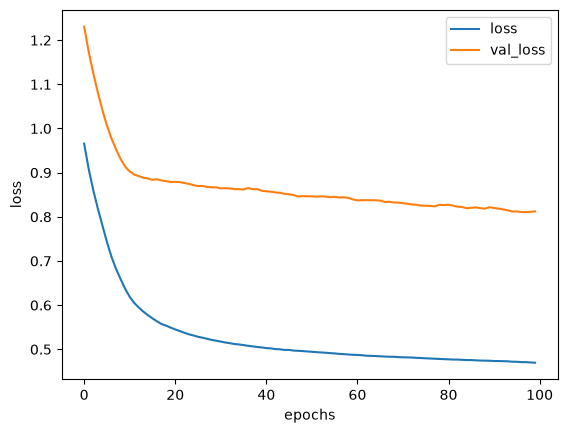

In [65]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
history_df[['loss', 'val_loss']].plot()
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

## 13.Multi-Feature Neural Network

In [66]:
# configure EarlyStopping parameters
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [67]:
# Use the validation
# Step 1: Define
# Select multiple numeric features and re-split/re-scale
X_multi = housing[['beds', 'baths', 'sq__ft', 'latitude', 'longitude']]
y_multi = housing['price']

X_train_all_m, X_test_m, y_train_all_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)
X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(X_train_all_m, y_train_all_m, test_size=0.2, random_state=42)

scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_val_m_scaled = scaler_m.transform(X_val_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

# scale the target too, same reasoning as before
y_scaler_m = StandardScaler()
y_train_m_scaled = y_scaler_m.fit_transform(y_train_m.values.reshape(-1, 1)).flatten()
y_val_m_scaled = y_scaler_m.transform(y_val_m.values.reshape(-1, 1)).flatten()
y_test_m_scaled = y_scaler_m.transform(y_test_m.values.reshape(-1, 1)).flatten()

model = Sequential()
model.add(Input(shape=(X_train_m.shape[1],)))
model.add(Dense(20, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='linear'))

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
history = model.fit(X_train_m_scaled, y_train_m_scaled, validation_data=(X_val_m_scaled, y_val_m_scaled),
                     epochs=100, batch_size=32, callbacks=[es])

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 1.0054 - mae: 0.6857 - val_loss: 0.9248 - val_mae: 0.6882
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7218 - mae: 0.5899 - val_loss: 0.8092 - val_mae: 0.6385
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6001 - mae: 0.5410 - val_loss: 0.7594 - val_mae: 0.6060
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5360 - mae: 0.5237 - val_loss: 0.7373 - val_mae: 0.5764
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4985 - mae: 0.5081 - val_loss: 0.7344 - val_mae: 0.5652
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4739 - mae: 0.4994 - val_loss: 0.7362 - val_mae: 0.5570
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4565 - mae: 0.4897 - val_loss: 0.7385 - val_mae: 0.5532
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4421 - mae: 0.4856 - val_loss: 0.7447 - val_mae: 0.5483
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.42

In [68]:
# Model Weights
model.weights

[<Variable path=sequential_16/dense_32/kernel, shape=(5, 20), dtype=float32, value=[[-0.49086255  0.27605867  0.44693875 -0.06491105  0.40616027 -0.43130267
   -0.12160687 -0.1256804  -0.19985746  0.12437637 -0.16019665  0.02608153
    0.22664054  0.3689781  -0.13295016  0.24250878  0.17549145  0.39661515
   -0.3833877  -0.2876211 ]
  [-0.10615173 -0.21946816  0.10880817 -0.15369825  0.2399793   0.49439064
   -0.06665826  0.4572382  -0.28900546 -0.35111353 -0.3387554   0.3373954
   -0.46029595 -0.24288538  0.29936677 -0.26284364  0.3392154   0.05652444
   -0.50728667  0.52137065]
  [ 0.38283235 -0.46188357 -0.32011506 -0.2959236   0.34722245 -0.15682214
   -0.51042765 -0.13967776 -0.32803908  0.03082548 -0.51398504 -0.24438444
    0.423267   -0.5208053  -0.20660521 -0.42635825  0.0627529   0.25120813
    0.16895135  0.52798456]
  [-0.4468663  -0.39651543  0.21116956 -0.34033808  0.20297378 -0.44538808
   -0.02378813 -0.19870462  0.2603471   0.08350693  0.12986632 -0.26019904
    0.1999

In [69]:
# Model Summary
model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 20)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 15)             │           315 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 904 (3.54 KB)

 Trainable params: 451 (1.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 453 (1.77 KB)

In [70]:
# Create a History Data Frame
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,val_loss,val_mae
0,1.005356,0.685748,0.924777,0.688193
1,0.721750,0.589938,0.809177,0.638540
2,0.600092,0.541030,0.759448,0.605979
3,0.536026,0.523703,0.737300,0.576357
4,0.498549,0.508140,0.734352,0.565204
5,0.473857,0.499446,0.736244,0.557045
6,0.456454,0.489656,0.738482,0.553177
7,0.442118,0.485607,0.744740,0.548297
8,0.429818,0.478778,0.749400,0.545991
9,0.416824,0.472342,0.753819,0.543664


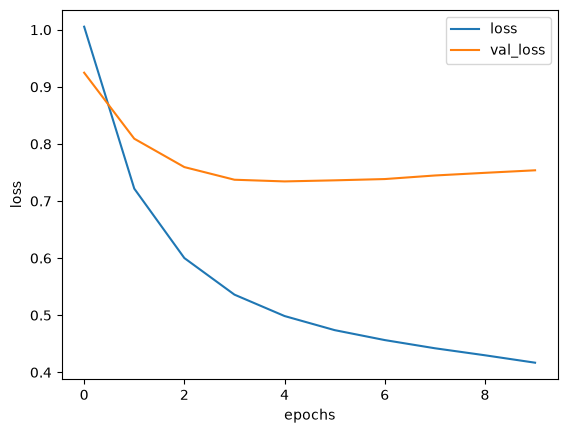

In [71]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
history_df[['loss', 'val_loss']].plot()
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()